# EDA básico — Dataset de compras

Este análisis explora el dataset y prepara tres variables:

- `Age`: codificación ordinal de los grupos etarios.
- `Stay_In_Current_City_Years`: conversión a años enteros.
- `Product_Subcategory_2`: reemplazo de nulos por `0`, que representa que el producto no posee una segunda subcategoría.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

Matplotlib is building the font cache; this may take a moment.


## 1. Carga e inspección inicial

In [2]:
df = pd.read_csv('dataset_compras.csv')

print(f'Dimensiones: {df.shape[0]:,} filas y {df.shape[1]} columnas')
display(df.head())
display(df.info())

Dimensiones: 182,721 filas y 11 columnas


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  object 
 2   Age                         182721 non-null  object 
 3   Gender                      182721 non-null  object 
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  object 
 6   Stay_In_Current_City_Years  182721 non-null  object 
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 15.3+ MB


None

In [3]:
# Resumen estadístico de las variables numéricas
display(df.describe().T)

# Conteo de valores nulos
nulos = df.isna().sum().sort_values(ascending=False)
display(pd.DataFrame({
    'nulos': nulos,
    'porcentaje': (nulos / len(df) * 100).round(2)
}).query('nulos > 0'))

,count,mean,std,min,25%,50%,75%,max
User_ID,182721.0,1.050060e+06,28840.399617,1000035.0,1024971.0,1050146.0,1074883.0,1099995.0
Marital_Status,182721.0,6.475665e-01,0.477729,0.0,0.0,1.0,1.0,1.0
Product_Category,182721.0,1.062912e+01,5.659703,1.0,5.0,11.0,16.0,20.0
Product_Subcategory_1,140903.0,2.455772e+01,12.550279,3.0,13.0,24.0,36.0,45.0
Product_Subcategory_2,77461.0,1.284348e+01,4.593955,5.0,9.0,13.0,17.0,20.0
Purchase,182721.0,7.851669e+03,8321.461408,45.0,578.0,5060.0,11930.0,29980.0


,nulos,porcentaje
Product_Subcategory_2,105260,57.61
Product_Subcategory_1,41818,22.89


## 2. Distribuciones principales

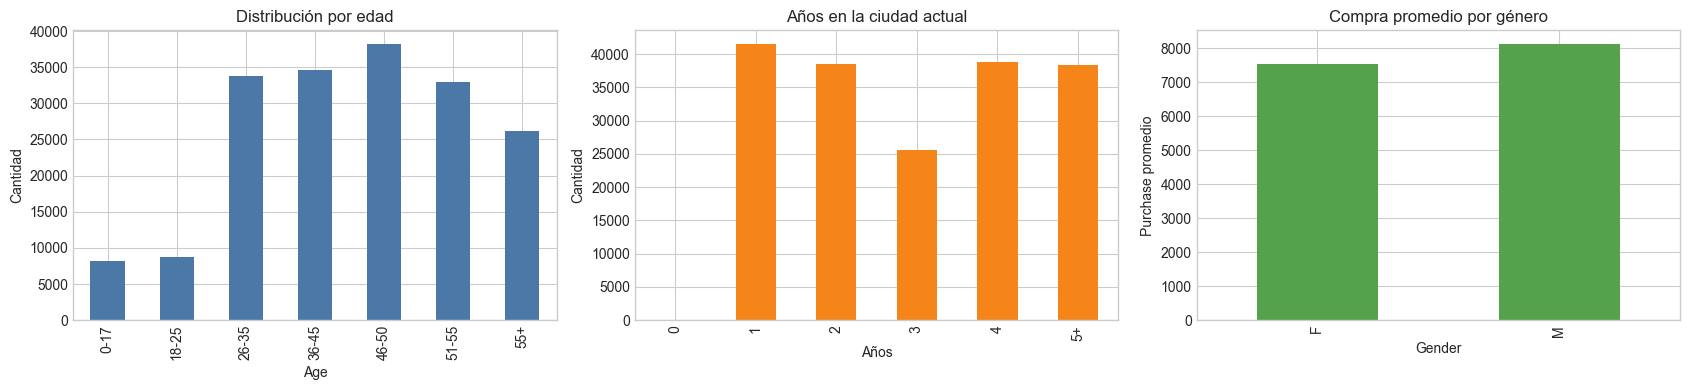

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

orden_age = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
orden_stay = ['0', '1', '2', '3', '4', '5+']

df['Age'].value_counts().reindex(orden_age).plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set(title='Distribución por edad', xlabel='Age', ylabel='Cantidad')

df['Stay_In_Current_City_Years'].value_counts().reindex(orden_stay).plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set(title='Años en la ciudad actual', xlabel='Años', ylabel='Cantidad')

df.groupby('Gender')['Purchase'].mean().plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set(title='Compra promedio por género', xlabel='Gender', ylabel='Purchase promedio')

plt.tight_layout()

## 3. Análisis de outliers en `Purchase`

Se utiliza el rango intercuartílico (IQR). Una observación se considera outlier si está por debajo de `Q1 - 1.5 × IQR` o por encima de `Q3 + 1.5 × IQR`. Como `Purchase` suele tener una cola derecha, se identifican los casos para analizarlos, pero no se eliminan sin una regla de negocio.

Q1: 578.00
Q3: 11,930.00
IQR: 11,352.00
Límite inferior: -16,450.00
Límite superior: 28,958.00
Outliers detectados: 1,808 (0.99%)
Valores recortados: 1,808


,User_ID,Product_ID,Product_Category,Purchase
144,1025718,P00052838,3,29870
164,1049141,P00008604,13,29390
780,1065401,P00008604,13,29390
806,1065755,P00052838,3,29870
823,1066966,P00082828,20,29630


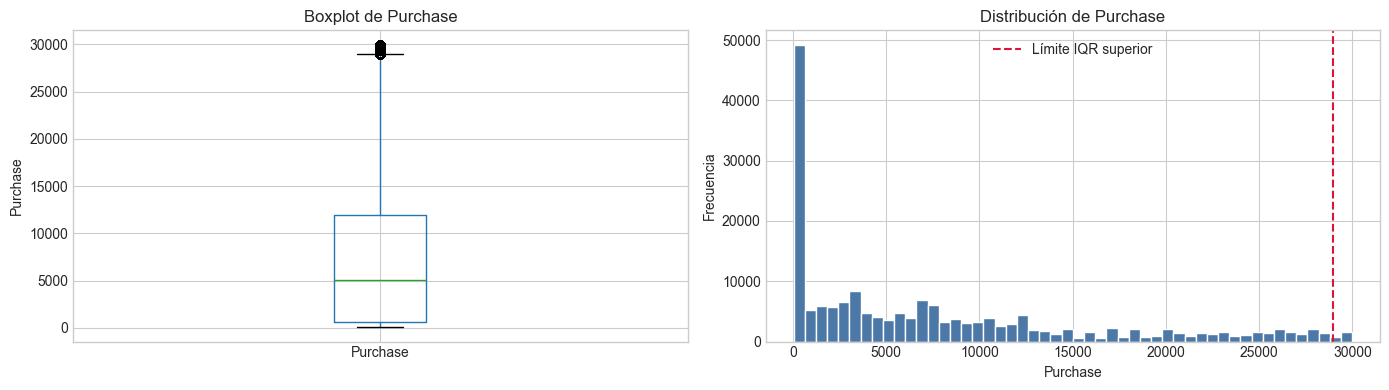

In [5]:
q1 = df['Purchase'].quantile(0.25)
q3 = df['Purchase'].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df['Purchase_Is_Outlier'] = (
    (df['Purchase'] < limite_inferior) | (df['Purchase'] > limite_superior)
)
outliers = df.loc[df['Purchase_Is_Outlier']]

print(f'Q1: {q1:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Límite inferior: {limite_inferior:,.2f}')
print(f'Límite superior: {limite_superior:,.2f}')
print(f'Outliers detectados: {len(outliers):,} ({len(outliers) / len(df):.2%})')

# Winsorización: se conserva Purchase original y se limita una copia.
df['Purchase_Clipped'] = df['Purchase'].clip(
    lower=limite_inferior, upper=limite_superior
)
valores_recortados = (df['Purchase'] != df['Purchase_Clipped']).sum()
print(f'Valores recortados: {valores_recortados:,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.boxplot(column='Purchase', ax=axes[0])
axes[0].set(title='Boxplot de Purchase', ylabel='Purchase')
axes[1].hist(df['Purchase'], bins=50, color='#4C78A8', edgecolor='white')
axes[1].axvline(limite_superior, color='crimson', linestyle='--', label='Límite IQR superior')
axes[1].set(title='Distribución de Purchase', xlabel='Purchase', ylabel='Frecuencia')
axes[1].legend()
plt.tight_layout()

display(outliers[['User_ID', 'Product_ID', 'Product_Category', 'Purchase']].head())

## 4. Tratamiento de nulos y encoding

Se evita imputar `Product_Subcategory_2` con una media porque es una variable categórica. Se usa `0` como categoría explícita para conservar todas las filas y señalar la ausencia de segunda subcategoría.

In [6]:
# Nulos: 0 significa 'sin segunda subcategoría'
nulos_subcategory_2 = df['Product_Subcategory_2'].isna().sum()
df['Product_Subcategory_2'] = df['Product_Subcategory_2'].fillna(0).astype('int64')

# Encoding ordinal de Age
age_encoder = {
    '0-17': 0, '18-25': 1, '26-35': 2, '36-45': 3,
    '46-50': 4, '51-55': 5, '55+': 6
}
df['Age_Encoded'] = df['Age'].map(age_encoder)

# Encoding de permanencia: 5+ se representa como 5
df['Stay_In_Current_City_Years_Encoded'] = (
    df['Stay_In_Current_City_Years'].replace('5+', '5').astype('int64')
)

print(f'Nulos tratados en Product_Subcategory_2: {nulos_subcategory_2:,} ({nulos_subcategory_2 / len(df):.2%})')
display(df[['Age', 'Age_Encoded', 'Stay_In_Current_City_Years',
            'Stay_In_Current_City_Years_Encoded', 'Product_Subcategory_2']].head())

Nulos tratados en Product_Subcategory_2: 105,260 (57.61%)


,Age,Age_Encoded,Stay_In_Current_City_Years,Stay_In_Current_City_Years_Encoded,Product_Subcategory_2
0,46-50,4,1,1,0
1,36-45,3,3,3,0
2,36-45,3,5+,5,0
3,36-45,3,1,1,8
4,46-50,4,5+,5,0


## 5. Asociación entre variables categóricas

Las variables analizadas son categorías, por lo que se usan tablas de contingencia y **V de Cramér**. El indicador va de 0 (sin asociación) a 1 (asociación perfecta); no indica causalidad ni una relación lineal.

In [7]:
def cramers_v(serie_a, serie_b):
    """Calcula V de Cramér a partir de una tabla de contingencia."""
    tabla = pd.crosstab(serie_a, serie_b)
    observados = tabla.to_numpy()
    total = observados.sum()
    esperados = np.outer(observados.sum(axis=1), observados.sum(axis=0)) / total
    chi2 = ((observados - esperados) ** 2 / esperados).sum()
    minimo_grados_libertad = min(observados.shape) - 1
    return 0.0 if minimo_grados_libertad == 0 else np.sqrt(chi2 / (total * minimo_grados_libertad))

def mostrar_tabla_y_asociacion(dataframe, variable_a, variable_b):
    tabla = pd.crosstab(dataframe[variable_a], dataframe[variable_b])
    tabla_porcentaje = pd.crosstab(
        dataframe[variable_a], dataframe[variable_b], normalize='index'
    ).mul(100).round(1)
    v_cramer = cramers_v(dataframe[variable_a], dataframe[variable_b])
    print(f'V de Cramér ({variable_a} vs {variable_b}): {v_cramer:.3f}')
    print('Porcentajes por fila:')
    display(tabla_porcentaje)
    return tabla, v_cramer

### City_Category y Stay_In_Current_City_Years

V de Cramér (City_Category vs Stay_In_Current_City_Years): 0.035
Porcentajes por fila:


Stay_In_Current_City_Years,1,2,3,4,5+
City_Category,,,,,
A,22.1,20.6,15.2,21.6,20.5
B,23.5,19.9,13.9,20.5,22.2
C,22.6,23.2,12.3,21.6,20.2


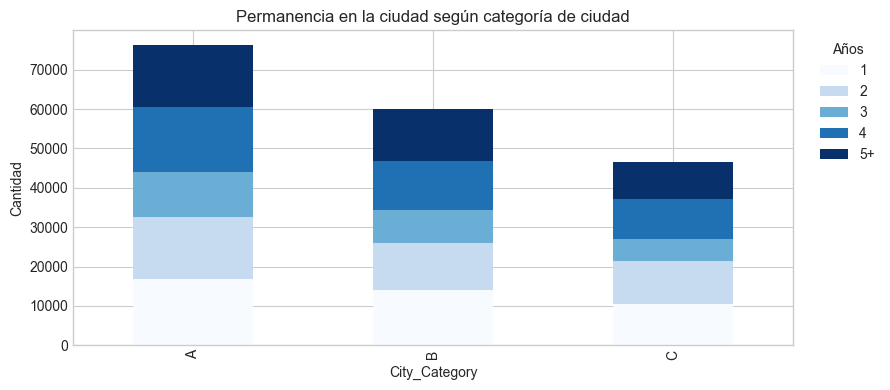

In [8]:
tabla_ciudad_estadia, v_ciudad_estadia = mostrar_tabla_y_asociacion(
    df, 'City_Category', 'Stay_In_Current_City_Years'
)

ax = tabla_ciudad_estadia.plot(kind='bar', stacked=True, figsize=(9, 4), colormap='Blues')
ax.set(title='Permanencia en la ciudad según categoría de ciudad',
       xlabel='City_Category', ylabel='Cantidad')
ax.legend(title='Años', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

### Product_Category, Product_Subcategory_1 y Product_Subcategory_2

`Product_Subcategory_2` usa el valor `0` para la categoría sin segunda subcategoría, según el tratamiento de nulos aplicado antes.

,Product_Category,Product_Subcategory_1,Product_Subcategory_2
Product_Category,1.000,0.234,0.099
Product_Subcategory_1,0.234,1.000,0.159
Product_Subcategory_2,0.099,0.159,1.000



Product_Category vs Product_Subcategory_1
V de Cramér (Product_Category vs Product_Subcategory_1): 0.234
Porcentajes por fila:


Product_Subcategory_1,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,18.0,20.0,21.0,22.0,24.0,25.0,26.0,27.0,28.0,30.0,32.0,33.0,35.0,36.0,39.0,40.0,42.0,44.0,45.0
Product_Category,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,8.1,0.0,5.2,0.0,0.0,0.0,0.0,5.9,0.0,0.0,0.0,11.9,11.3,0.0,0.0,0.0,0.0,7.9,8.3,10.9,0.0,0.0,2.9,5.2,0.0,8.3,8.5,0.0,5.7
2,5.3,0.0,5.1,4.8,0.0,0.0,2.8,5.5,0.0,7.1,0.0,0.0,4.2,0.0,7.3,3.0,7.5,0.0,7.6,2.6,0.0,7.6,0.0,11.8,0.0,2.9,2.3,7.4,0.0,0.0,0.0,0.0,5.3
3,0.5,0.0,1.0,1.1,3.9,0.0,2.0,4.1,2.3,3.5,3.5,5.5,2.6,0.0,3.4,6.3,2.5,3.4,4.3,0.9,4.5,1.8,5.4,4.3,0.0,0.5,5.5,6.2,1.9,5.4,4.2,6.7,2.6
4,0.0,7.7,0.0,6.4,0.0,4.2,0.0,0.0,0.0,7.4,0.0,0.0,0.0,8.2,5.7,9.0,0.0,0.0,5.4,0.0,0.0,0.0,8.0,7.7,7.1,0.0,0.0,2.2,0.0,9.9,5.0,6.2,0.0
5,0.0,8.4,0.0,10.3,0.0,2.1,0.0,0.0,0.0,4.8,0.0,0.0,0.0,5.8,6.3,5.6,0.0,0.0,7.8,0.0,0.0,0.0,5.1,5.5,7.7,0.0,0.0,6.8,0.0,8.3,5.4,10.0,0.0
6,0.0,0.0,0.0,0.0,8.5,0.0,7.9,9.8,0.0,0.0,0.0,4.8,0.0,0.0,5.5,2.0,8.7,0.0,0.0,0.0,0.0,7.9,9.8,2.3,0.0,0.0,4.5,8.6,0.0,3.2,8.4,0.0,8.2
7,0.0,0.0,0.0,0.0,2.9,0.0,3.3,7.1,0.0,0.0,0.0,4.3,0.0,0.0,5.2,11.1,1.8,0.0,0.0,0.0,0.0,9.7,11.5,2.2,0.0,0.0,8.5,9.9,0.0,8.4,7.5,0.0,6.6
8,3.6,0.0,2.5,4.3,2.2,0.0,7.5,13.2,0.0,0.0,0.0,2.2,3.6,0.0,13.0,0.0,2.1,0.0,0.0,5.0,0.0,5.0,0.0,8.8,0.0,1.9,6.4,7.1,1.1,5.6,5.0,0.0,0.0
9,0.0,0.0,0.0,0.0,9.1,0.0,5.6,6.6,0.0,0.0,0.0,5.2,0.0,0.0,5.8,7.9,7.3,0.0,0.0,0.0,0.0,10.3,5.6,9.7,0.0,0.0,7.2,4.5,0.0,4.3,7.5,0.0,3.4



Product_Category vs Product_Subcategory_2
V de Cramér (Product_Category vs Product_Subcategory_2): 0.099
Porcentajes por fila:


Product_Subcategory_2,0,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Product_Category,,,,,,,,,,,,,,,,,
1,64.7,0.0,0.0,0.0,2.0,0.0,4.3,2.1,4.3,0.0,4.6,0.0,4.5,4.5,0.0,7.0,2.1
2,51.0,2.1,8.7,1.7,2.0,1.8,6.0,0.0,4.3,4.1,0.0,1.9,4.7,3.4,6.3,2.1,0.0
3,58.7,0.7,1.1,3.8,3.0,3.5,2.9,2.6,1.3,0.8,3.3,4.7,2.2,1.0,4.9,2.1,3.3
4,57.4,0.6,1.1,3.1,1.7,3.1,4.8,1.3,4.2,0.7,2.7,5.3,4.3,3.1,2.8,1.2,2.6
5,58.3,2.2,3.6,1.0,2.0,2.2,2.3,6.4,2.1,1.6,1.7,1.4,1.5,5.1,1.8,4.1,2.7
6,59.9,3.9,1.6,1.1,1.0,2.5,4.5,1.6,2.8,1.8,4.7,2.6,1.9,2.5,3.2,2.7,1.8
7,62.4,1.6,1.8,2.9,4.9,1.7,0.0,1.7,6.0,2.6,0.7,0.8,1.8,3.1,2.9,1.5,3.6
8,50.8,5.5,1.4,1.8,8.7,0.0,3.1,3.5,3.1,0.7,3.8,5.8,1.0,0.8,2.7,5.6,1.6
9,58.6,0.8,3.5,3.4,2.2,2.3,2.8,1.4,0.6,2.2,4.8,0.7,2.8,1.5,4.7,3.9,4.0



Product_Subcategory_1 vs Product_Subcategory_2
V de Cramér (Product_Subcategory_1 vs Product_Subcategory_2): 0.159
Porcentajes por fila:


Product_Subcategory_2,0,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Product_Subcategory_1,,,,,,,,,,,,,,,,,
3.0,54.4,0.0,0.0,6.1,0.0,0.0,7.0,0.0,6.8,0.0,0.0,0.0,0.0,0.0,6.7,13.3,5.7
4.0,51.9,5.3,0.0,0.0,1.5,1.5,3.5,6.7,1.5,2.5,0.0,2.7,4.8,9.4,0.0,2.6,6.0
5.0,28.8,7.7,0.0,14.9,0.0,8.6,8.9,0.0,0.0,14.4,0.0,0.0,7.1,0.0,9.7,0.0,0.0
6.0,62.6,1.9,4.5,1.3,2.3,1.1,2.2,3.5,1.0,1.7,1.3,3.5,2.4,0.0,4.4,3.7,2.4
7.0,68.2,0.9,3.9,5.4,0.0,3.3,0.0,2.2,0.8,0.0,0.8,0.0,1.7,2.5,0.7,3.0,6.5
8.0,64.6,0.0,0.0,4.8,4.4,6.9,1.7,5.1,0.0,0.0,0.0,2.7,2.2,0.0,2.1,0.0,5.4
9.0,43.5,5.5,6.3,5.6,4.2,1.8,4.2,2.1,2.8,0.0,0.0,9.0,2.9,0.0,6.7,4.1,1.3
10.0,58.3,0.8,2.9,1.8,8.1,0.0,2.8,1.2,8.6,0.0,2.4,4.3,0.9,1.5,1.4,0.0,5.1
11.0,23.5,21.9,0.0,32.8,0.0,0.0,11.2,0.0,0.0,10.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0


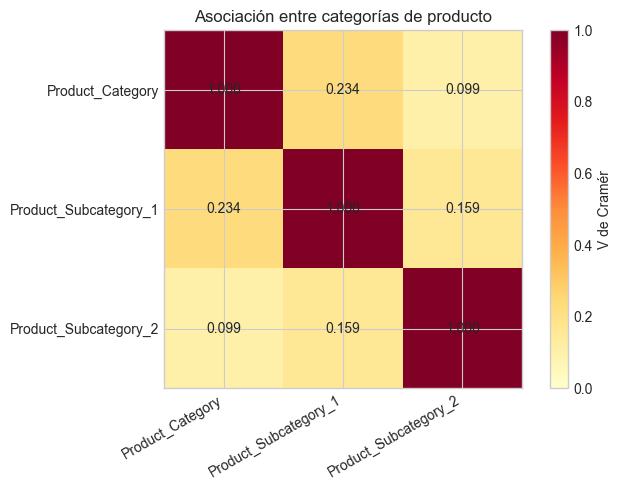

In [9]:
variables_producto = [
    'Product_Category', 'Product_Subcategory_1', 'Product_Subcategory_2'
]
asociaciones_producto = pd.DataFrame(
    np.eye(len(variables_producto)),
    index=variables_producto, columns=variables_producto
)

for indice, variable_a in enumerate(variables_producto):
    for variable_b in variables_producto[indice + 1:]:
        valor = cramers_v(df[variable_a], df[variable_b])
        asociaciones_producto.loc[variable_a, variable_b] = valor
        asociaciones_producto.loc[variable_b, variable_a] = valor

display(asociaciones_producto.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
imagen = ax.imshow(asociaciones_producto, vmin=0, vmax=1, cmap='YlOrRd')
ax.set_xticks(range(len(variables_producto)), variables_producto, rotation=30, ha='right')
ax.set_yticks(range(len(variables_producto)), variables_producto)
for fila in range(len(variables_producto)):
    for columna in range(len(variables_producto)):
        ax.text(columna, fila, f'{asociaciones_producto.iloc[fila, columna]:.3f}',
                ha='center', va='center')
fig.colorbar(imagen, ax=ax, label='V de Cramér')
ax.set_title('Asociación entre categorías de producto')
plt.tight_layout()

for variable_a, variable_b in [
    ('Product_Category', 'Product_Subcategory_1'),
    ('Product_Category', 'Product_Subcategory_2'),
    ('Product_Subcategory_1', 'Product_Subcategory_2'),
]:
    print(f'\n{variable_a} vs {variable_b}')
    mostrar_tabla_y_asociacion(df, variable_a, variable_b)

## 6. Tabla para modelado por cliente

Cada fila representa un cliente. `Precio_Promedio` es el objetivo a modelar y se calcula desde `Purchase_Clipped` para que los valores extremos no dominen el promedio. `User_ID` se conserva únicamente como identificador: debe excluirse de las variables de entrada de la red.

In [10]:
# Verificación: las variables demográficas deben ser constantes por cliente.
atributos_fijos = ['Age_Encoded', 'Gender', 'Marital_Status', 'City_Category']
variacion_por_cliente = df.groupby('User_ID')[atributos_fijos].nunique()
assert (variacion_por_cliente <= 1).all().all(), (
    'Hay clientes con atributos demográficos inconsistentes.'
)

# Gender es binario; Marital_Status ya está codificada como 0/1.
gender_encoder = {'F': 0, 'M': 1}
df['Gender_Encoded'] = df['Gender'].map(gender_encoder).astype('int8')
df['Marital_Status_Encoded'] = df['Marital_Status'].astype('int8')

# City_Category no tiene orden natural: se codifica con one-hot encoding.
ciudad_encoded = pd.get_dummies(
    df[['User_ID', 'City_Category']], columns=['City_Category'], dtype='int8'
).groupby('User_ID').max()

tabla_clientes = (
    df.groupby('User_ID')
    .agg(
        Age_Encoded=('Age_Encoded', 'first'),
        Gender_Encoded=('Gender_Encoded', 'first'),
        Marital_Status_Encoded=('Marital_Status_Encoded', 'first'),
        Stay_In_Current_City_Years_Promedio=(
            'Stay_In_Current_City_Years_Encoded', 'mean'
        ),
        Cantidad_Compras=('Purchase', 'size'),
        Precio_Promedio=('Purchase_Clipped', 'mean'),
    )
    .join(ciudad_encoded)
    .reset_index()
)

# Las columnas City_Category_* son la versión encoded de la ciudad.
columnas_modelo = [
    'User_ID', 'Age_Encoded', 'Gender_Encoded', 'Marital_Status_Encoded',
    'City_Category_A', 'City_Category_B', 'City_Category_C',
    'Stay_In_Current_City_Years_Promedio', 'Cantidad_Compras',
    'Precio_Promedio',
]
tabla_clientes = tabla_clientes[columnas_modelo]

print(f'Clientes: {len(tabla_clientes):,}')
display(tabla_clientes.head())
display(tabla_clientes.describe().T)

Clientes: 7,432


,User_ID,Age_Encoded,Gender_Encoded,Marital_Status_Encoded,City_Category_A,City_Category_B,City_Category_C,Stay_In_Current_City_Years_Promedio,Cantidad_Compras,Precio_Promedio
0,1000035,1,1,0,1,0,0,1.0,13,1912.923077
1,1000044,3,1,1,1,0,0,4.0,43,14326.534884
2,1000070,4,1,1,0,1,0,4.0,42,4120.809524
3,1000087,6,0,1,0,0,1,4.0,41,11228.219512
4,1000115,4,0,1,0,0,1,2.0,17,4673.882353


,count,mean,std,min,25%,50%,75%,max
User_ID,7432.0,1.049772e+06,28832.028398,1.000035e+06,1.024772e+06,1.049775e+06,1.074651e+06,1.099995e+06
Age_Encoded,7432.0,3.368541e+00,1.757218,0.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00
Gender_Encoded,7432.0,5.248924e-01,0.499414,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Marital_Status_Encoded,7432.0,5.933800e-01,0.491236,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
City_Category_A,7432.0,3.879171e-01,0.487308,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
City_Category_B,7432.0,3.382670e-01,0.473152,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
City_Category_C,7432.0,2.738159e-01,0.445946,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Stay_In_Current_City_Years_Promedio,7432.0,2.626211e+00,1.425757,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,5.000000e+00
Cantidad_Compras,7432.0,2.458571e+01,13.686571,1.000000e+01,1.400000e+01,1.800000e+01,4.000000e+01,5.000000e+01
Precio_Promedio,7432.0,6.744528e+03,3293.440247,2.752727e+02,4.247396e+03,6.329033e+03,8.510864e+03,1.723114e+04


## 7. Validación y exportación

In [11]:
# Verificar que no se introdujeron valores faltantes en las columnas transformadas
columnas_transformadas = [
    'Product_Subcategory_2', 'Age_Encoded', 'Stay_In_Current_City_Years_Encoded',
    'Purchase_Clipped'
]
assert df[columnas_transformadas].isna().sum().sum() == 0
assert df['Purchase_Clipped'].between(limite_inferior, limite_superior).all()

df.to_csv('dataset_compras_procesado.csv', index=False)
tabla_clientes.to_csv('tabla_clientes_modelado.csv', index=False)
print('Archivo creado: dataset_compras_procesado.csv')
print('Archivo creado: tabla_clientes_modelado.csv')
display(df.head())

Archivo creado: dataset_compras_procesado.csv
Archivo creado: tabla_clientes_modelado.csv


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase,Purchase_Is_Outlier,Purchase_Clipped,Age_Encoded,Stay_In_Current_City_Years_Encoded,Gender_Encoded,Marital_Status_Encoded
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,0,1810,False,1810,4,1,0,1
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,0,12351,False,12351,3,3,1,0
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,0,127,False,127,3,5,1,1
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8,2214,False,2214,3,1,1,1
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,0,7142,False,7142,4,5,1,1
